In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from imblearn.over_sampling import SMOTE
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

### Load Data

In [2]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,status,province_Gandaki Province,province_Karnali Province,province_Province 1,province_Province 2,province_Province 5,province_Sudoorpaschim Province
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


### Train-test split

In [3]:
X = df.drop(columns=['status'])
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# SMOTE oversampling
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# TabNet

In [8]:
# Convert to numpy and float32
X_train_sm = X_train_sm.values.astype(np.float32) if isinstance(X_train_sm, pd.DataFrame) else X_train_sm.astype(np.float32)
X_test = X_test.values.astype(np.float32) if isinstance(X_test, pd.DataFrame) else X_test.astype(np.float32)
y_train_sm = y_train_sm if isinstance(y_train_sm, np.ndarray) else np.array(y_train_sm)
y_test = y_test if isinstance(y_test, np.ndarray) else np.array(y_test)

In [9]:

# Initialize TabNetClassifier
tabnet = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1,
    seed=42
)

# Fit the model
tabnet.fit(
    X_train=X_train_sm, y_train=y_train_sm,
    eval_set=[(X_test, y_test)],
    eval_name=['valid'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.77051 | valid_accuracy: 0.52098 |  0:00:00s
epoch 1  | loss: 0.66426 | valid_accuracy: 0.61709 |  0:00:01s
epoch 2  | loss: 0.6425  | valid_accuracy: 0.63921 |  0:00:01s
epoch 3  | loss: 0.61374 | valid_accuracy: 0.54767 |  0:00:02s
epoch 4  | loss: 0.58934 | valid_accuracy: 0.54081 |  0:00:02s
epoch 5  | loss: 0.58455 | valid_accuracy: 0.56751 |  0:00:03s
epoch 6  | loss: 0.57427 | valid_accuracy: 0.60412 |  0:00:03s
epoch 7  | loss: 0.56265 | valid_accuracy: 0.64073 |  0:00:04s
epoch 8  | loss: 0.56626 | valid_accuracy: 0.6804  |  0:00:04s
epoch 9  | loss: 0.55866 | valid_accuracy: 0.6926  |  0:00:05s
epoch 10 | loss: 0.54644 | valid_accuracy: 0.70404 |  0:00:05s
epoch 11 | loss: 0.54529 | valid_accuracy: 0.68574 |  0:00:06s
epoch 12 | loss: 0.54097 | valid_accuracy: 0.70938 |  0:00:06s
epoch 13 | loss: 0.53797 | valid_accuracy: 0.69565 |  0:00:07s
epoch 14 | loss: 0.53546 | valid_accuracy: 0.7193  |  0:00:07s
epoch 15 | loss: 0.53223 | valid_accuracy: 0.72616 |  0

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [10]:
y_pred = tabnet.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred, digits=3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.775     0.740     0.757       707
           1      0.711     0.748     0.729       604

    accuracy                          0.744      1311
   macro avg      0.743     0.744     0.743      1311
weighted avg      0.745     0.744     0.744      1311




In [11]:
y_probas = tabnet.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.8079600701961377


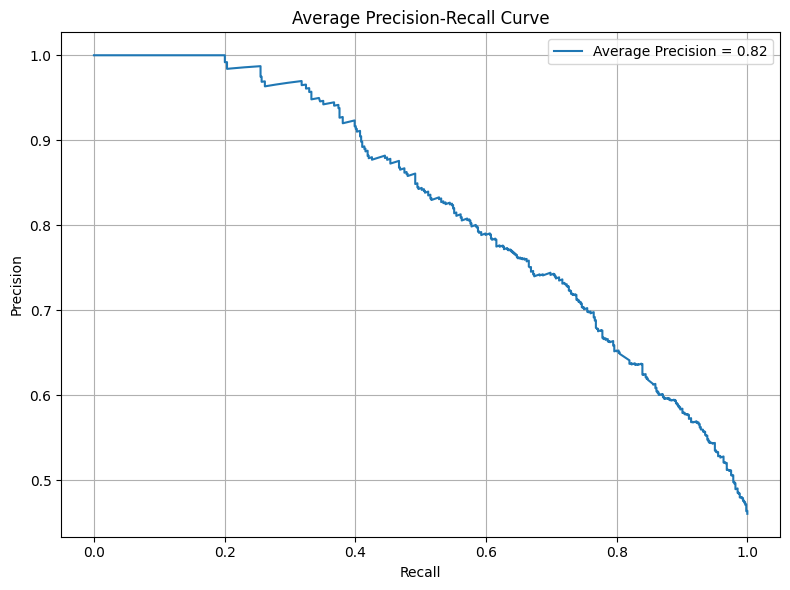

In [27]:
# Compute precision-recall curve and average precision
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)
avg_precision = average_precision_score(y_test, y_probas)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Average Precision = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Average Precision-Recall Curve')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Tuned Model

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
# from sklearn.metrics import make_scorer, recall_score
# from pytorch_tabnet.tab_model import TabNetClassifier
# import torch
# import numpy as np

# class TabNetWrapper(TabNetClassifier):
#     def fit(self, X, y):
#         if hasattr(X, "values"):
#             X = X.values
#         if hasattr(y, "values"):
#             y = y.values
#         X = X.astype(np.float32)
#         y = y.astype(int)

#         return super().fit(
#             X, y,
#             eval_set=[(X, y)],
#             eval_name=['valid'],
#             eval_metric=['accuracy'],
#             max_epochs=100,
#             patience=10,
#             batch_size=256,
#             virtual_batch_size=128
#         )


# # 2. Define parameter grid
# param_dist = {
#     'n_d': [8, 16, 32],
#     'n_a': [8, 16, 32],
#     'n_steps': [3, 5],
#     'gamma': [1.0, 1.3],
#     'lambda_sparse': [0.0001, 0.001],
#     'momentum': [0.02, 0.1],
#     'optimizer_params': [{'lr': 0.01}, {'lr': 0.02}],
# }

# # 3. Make sure original X, y are numpy arrays
# X = X.values.astype(np.float32) if hasattr(X, "values") else X.astype(np.float32)
# y = y.values if hasattr(y, "values") else y

# # 4. Set up cross-validation
# skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# tabnet_search = GridSearchCV(
#     estimator=TabNetWrapper(
#         optimizer_fn=torch.optim.Adam,
#         scheduler_fn=torch.optim.lr_scheduler.StepLR,
#         scheduler_params={"step_size": 10, "gamma": 0.9},
#         verbose=0,
#         seed=42,
#         device_name='cuda'  # If you have GPU, otherwise use 'cpu'
#     ),
#     param_grid=param_dist,
#     scoring=make_scorer(recall_score),
#     cv=skf,
#     verbose=2,
#     n_jobs=1,
#     error_score='raise'
# )

# # 6. Run the search
# tabnet_search.fit(X, y)

# # 7. Show best results
# print("✅ Best Recall:", tabnet_search.best_score_)
# print("📊 Best Parameters:", tabnet_search.best_params_)

# best_model = tabnet_search.best_estimator_
# y_pred = best_model.predict(X_test.astype(np.float32))
# print(classification_report(y_test, y_pred, digits=3))

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
import torch

class TabNetWrapper(TabNetClassifier):
    def fit(self, X, y):
        if hasattr(X, "values"):
            X = X.values
        if hasattr(y, "values"):
            y = y.values
        X = X.astype(np.float32)
        y = y.astype(int)

        return super().fit(
            X, y,
            eval_set=[(X, y)],
            eval_name=['valid'],
            eval_metric=['accuracy'],
            max_epochs=100,
            patience=10,
            batch_size=256,
            virtual_batch_size=256
        )


# 2. Define parameter grid
param_dist = {
    'n_d': [8, 16, 32],
    'n_a': [8, 16, 32],
    'n_steps': [3, 5],
    'gamma': [1.0, 1.3],
    'lambda_sparse': [0.0001, 0.001],
    'momentum': [0.02, 0.1],
    'optimizer_params': [{'lr': 0.01}, {'lr': 0.02}],
}

# 3. Make sure original X, y are numpy arrays
X = X.values.astype(np.float32) if hasattr(X, "values") else X.astype(np.float32)
y = y.values if hasattr(y, "values") else y

tabnet_search = RandomizedSearchCV(
    estimator=TabNetWrapper(
        optimizer_fn=torch.optim.Adam,
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 10, "gamma": 0.9},
        verbose=0,
        seed=42,
        device_name='cuda'  # <-- ENABLE GPU
    ),
    param_distributions=param_dist,
    scoring=make_scorer(recall_score),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_iter=10,
    verbose=2,
    n_jobs=1,
    error_score='raise'
)

# 6. Run the search
tabnet_search.fit(X, y)

best_model = tabnet_search.best_estimator_
y_pred = best_model.predict(X_test.values.astype(np.float32))
print(classification_report(y_test, y_pred, digits=3))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Stop training because you reached max_epochs = 100 with best_epoch = 91 and best_valid_accuracy = 0.79945


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[CV] END gamma=1.0, lambda_sparse=0.001, momentum=0.02, n_a=8, n_d=8, n_steps=3, optimizer_params={'lr': 0.01}; total time=  51.9s

Early stopping occurred at epoch 37 with best_epoch = 27 and best_valid_accuracy = 0.76328


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[CV] END gamma=1.0, lambda_sparse=0.001, momentum=0.02, n_a=8, n_d=8, n_steps=3, optimizer_params={'lr': 0.01}; total time=  19.0s

Early stopping occurred at epoch 53 with best_epoch = 43 and best_valid_accuracy = 0.7674


...

[CV] END gamma=1.3, lambda_sparse=0.001, momentum=0.1, n_a=8, n_d=8, n_steps=5, optimizer_params={'lr': 0.02}; total time=  59.1s

Early stopping occurred at epoch 36 with best_epoch = 26 and best_valid_accuracy = 0.75687


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


[CV] END gamma=1.3, lambda_sparse=0.001, momentum=0.1, n_a=8, n_d=8, n_steps=5, optimizer_params={'lr': 0.02}; total time=  24.7s

Early stopping occurred at epoch 45 with best_epoch = 35 and best_valid_accuracy = 0.76755


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


KeyError: 0

In [6]:
best_model = tabnet_search.best_estimator_
y_pred = best_model.predict(X_test.values.astype(np.float32))
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.756     0.839     0.795       707
           1      0.784     0.684     0.730       604

    accuracy                          0.767      1311
   macro avg      0.770     0.761     0.763      1311
weighted avg      0.769     0.767     0.765      1311



In [ ]:
best_model = tabnet_search.best_estimator_
y_pred = best_model.predict(X_test.astype(np.float32))
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.747     0.835     0.788       707
           1      0.775     0.669     0.718       604

    accuracy                          0.758      1311
   macro avg      0.761     0.752     0.753      1311
weighted avg      0.760     0.758     0.756      1311



In [46]:
y_probas = best_model.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.838045208041671


In [47]:
from sklearn.metrics import roc_auc_score

# Assuming you have predictions as probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]  # Probability of class 1
auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc:.4f}")

AUC: 0.8348


In [48]:
import numpy as np
from sklearn.utils import resample

n_bootstraps = 1000
rng_seed = 42
bootstrapped_scores = []

np.random.seed(rng_seed)
for _ in range(n_bootstraps):
    indices = resample(np.arange(len(y_test)))
    if len(np.unique(y_test[indices])) < 2:
        continue  # skip if only one class in the sample
    score = roc_auc_score(y_test[indices], y_prob[indices])
    bootstrapped_scores.append(score)

# 95% CI
sorted_scores = np.array(bootstrapped_scores)
sorted_scores.sort()
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]

print(f"AUC: {auc:.4f}, 95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")


AUC: 0.8348, 95% CI: (0.8122, 0.8551)


In [49]:
from sklearn.metrics import cohen_kappa_score

# For predicted labels (not probabilities)
y_pred = best_model.predict(X_test)
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")


Cohen's Kappa: 0.5085
